## Data Understanding and Preprocessing

In [7]:
Data and Library import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Load the dataset
df = pd.read_csv("WEATHER_REPORTS.CSV")


## Data Cleaning 

In [8]:
Column names adjustment
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[^\w\s]', '', regex=True)

# datetime index
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df.set_index('date', inplace=True)

# Rename for clarity
df.rename(columns={'merra2_precipitation_corrected_mmday': 'precip'}, inplace=True)

# Remove missing values
df = df.dropna(subset=['precip'])


## Feature Engineering

In [9]:
# Aggregating daily to monthly precipitation totals
monthly_precip = df['precip'].resample('M').sum()

# Calculate 6-month rolling sum
rolling_6 = monthly_precip.rolling(window=6).sum()

# Compute SPI-6 using Z-score
spi_6 = zscore(rolling_6, nan_policy='omit')

# Build a new DataFrame
spi_df = pd.DataFrame({
    'month': rolling_6.index,
    'precip_6mo_sum': rolling_6.values,
    'spi_6': spi_6
}).dropna()


C:\Users\469775\AppData\Local\Temp\ipykernel_3848\4147706212.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_precip = df['precip'].resample('M').sum()


 ## Model Development

In [10]:
# Defining thresholds to use
drought_threshold = -1.0       # SPI < -1 indicates drought
heavy_rain_threshold = 1.5     # SPI > 1.5 indicates extreme wetness

# Variable fefinition for drought and heavy rain events
spi_df['drought'] = spi_df['spi_6'] < drought_threshold
spi_df['heavy_rain'] = spi_df['spi_6'] > heavy_rain_threshold

# Count frequency
drought_count = spi_df['drought'].sum()
heavy_rain_count = spi_df['heavy_rain'].sum()

# Find magnitudes (minimum/maximum SPI)
max_drought = spi_df.loc[spi_df['spi_6'].idxmin()]
max_rain = spi_df.loc[spi_df['spi_6'].idxmax()]


## Choosing Algorithms and Feature Selection

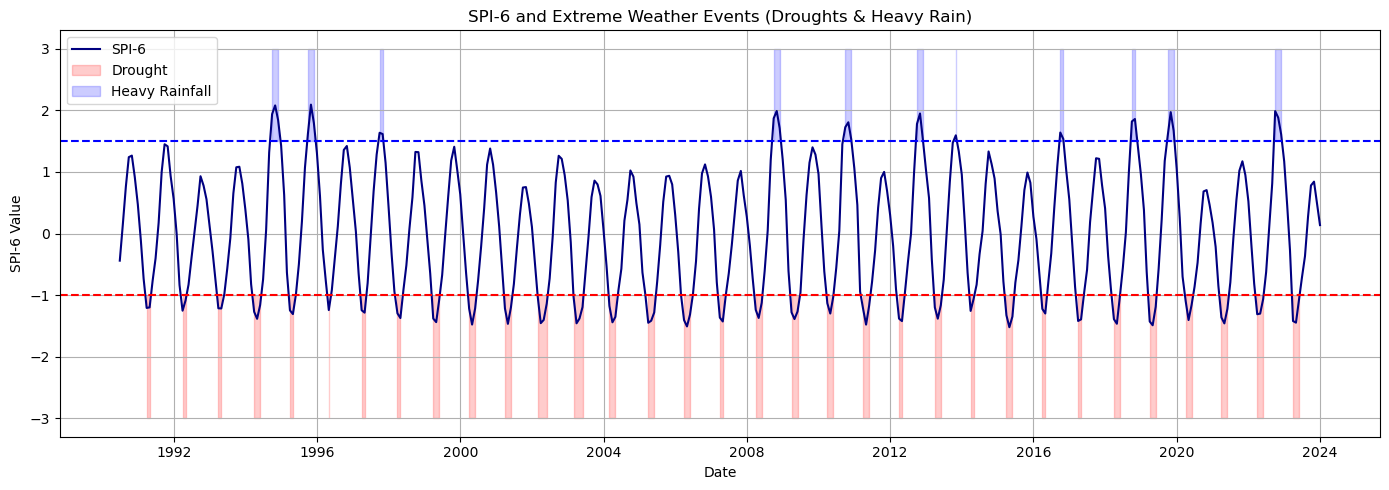

In [11]:
#graph ploting
plt.figure(figsize=(14, 5))
plt.plot(spi_df['month'], spi_df['spi_6'], label='SPI-6', color='navy')
plt.fill_between(spi_df['month'], -3, -1, where=spi_df['drought'], color='red', alpha=0.2, label='Drought')
plt.fill_between(spi_df['month'], 1.5, 3, where=spi_df['heavy_rain'], color='blue', alpha=0.2, label='Heavy Rainfall')
plt.axhline(-1, color='red', linestyle='--')
plt.axhline(1.5, color='blue', linestyle='--')
plt.title("SPI-6 and Extreme Weather Events (Droughts & Heavy Rain)")
plt.xlabel("Date")
plt.ylabel("SPI-6 Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Model Interpretation and Deployment
## Extreme weather conditions 1995, 1996, 2009 etc


## Ethical Considerations
Data validates historical extreme weather conditions but it is not enough to make conclusions for climate conditions